In [1]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
df_instacart = pd.read_csv("../data/processed/instacart.csv")

In [6]:
#Quick checks on the instacart DataFrame
df_instacart.head()

,order_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,train,11,4,8,14.0,196,1,1,Soda,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,train,11,4,8,14.0,25133,2,1,Organic String Cheese,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,train,11,4,8,14.0,38928,3,1,0% Greek Strained Yogurt,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,train,11,4,8,14.0,26405,4,1,XL Pick-A-Size Paper Towel Rolls,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,train,11,4,8,14.0,39657,5,1,Milk Chocolate Almonds,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [7]:
df_instacart.shape

(1384706, 26)

In [8]:
df_instacart.columns

Index(['order_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'product_id',
       'add_to_cart_order', 'reordered', 'product_name', 'aisle_id',
       'department_id', 'prices', 'department', 'aisle', 'First Name',
       'Surnam', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division'],
      dtype='str')

In [9]:
#Visualizing Orders by Day of Week
#Example 1: On which days of the week are orders placed most frequently?
#Preparing the data
orders_by_day = (
    df_instacart[["order_id", "order_dow"]]
    .drop_duplicates()
    .groupby("order_dow")
    .size()
)

orders_by_day


order_dow
0    27465
1    19672
2    16119
3    15687
4    15959
5    17406
6    18901
dtype: int64

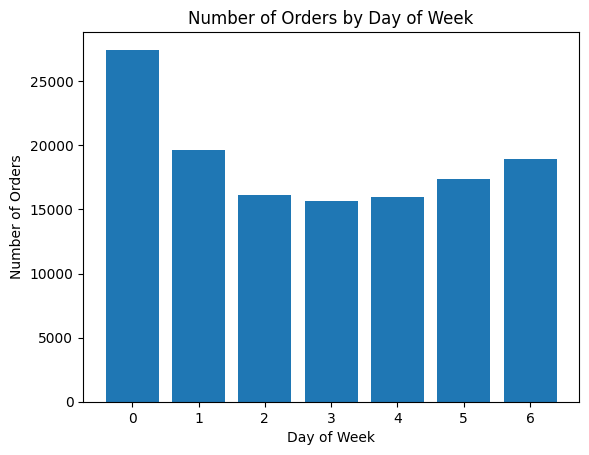

In [10]:
orders_by_day = (
    df_instacart[["order_id", "order_dow"]]
    .drop_duplicates()
    .groupby("order_dow")
    .size()
)

plt.figure()
plt.bar(orders_by_day.index, orders_by_day.values)
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.show()

In [12]:
#Example 2: Visualizing Orders by Hour of Day
#At what hours are orders placed most frequently?
#Preparing the data
orders_by_hour = (
    df_instacart[["order_id", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby("order_hour_of_day")
    .size()
)

orders_by_hour.head()

order_hour_of_day
0    852
1    507
2    305
3    223
4    218
dtype: int64

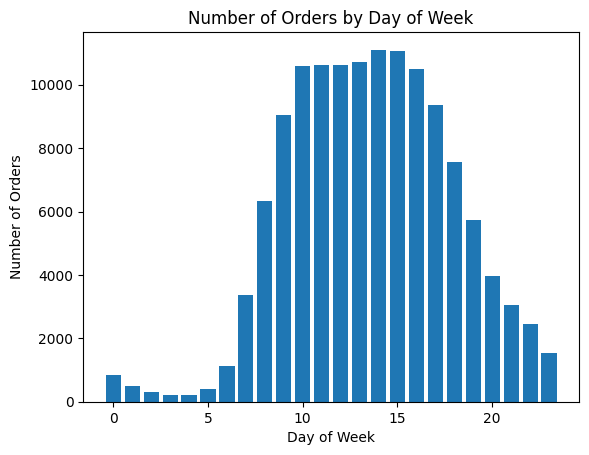

In [13]:
#creating the chart
orders_by_hour = (
    df_instacart[["order_id", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby("order_hour_of_day")
    .size()
)

plt.figure()
plt.bar(orders_by_hour.index, orders_by_hour.values)
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.show()

In [16]:
#Example 3: Visualizing the Most Popular Departments
#Which departments appear most often in the dataset?
#Preparing the data
top_departments = df_instacart["department"].value_counts().head(10)
top_departments

department
produce            409087
dairy eggs         217051
snacks             118862
beverages          113962
frozen             100426
pantry              81242
bakery              48394
canned goods        46799
deli                44291
dry goods pasta     38713
Name: count, dtype: int64

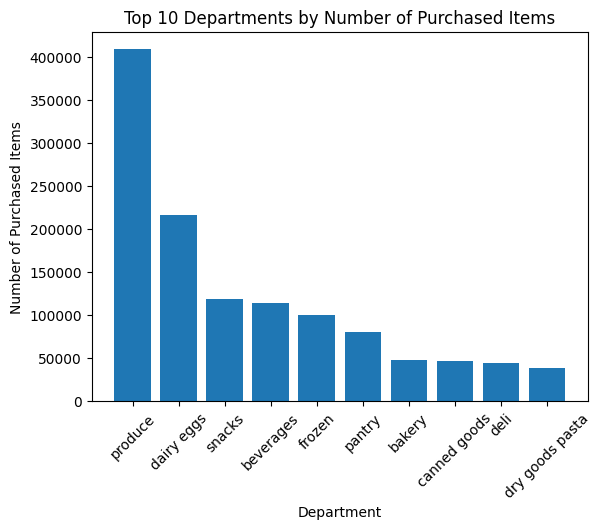

In [17]:
#creating the chart
top_departments = df_instacart["department"].value_counts().head(10)

plt.figure()
plt.bar(top_departments.index, top_departments.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Department")
plt.ylabel("Number of Purchased Items")
plt.xticks(rotation=45)
plt.show()


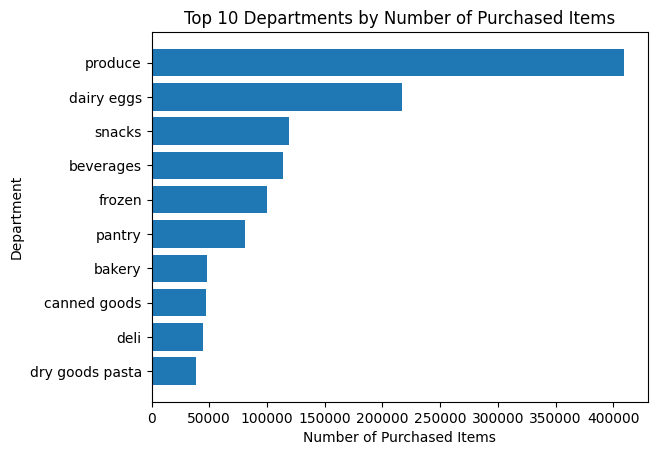

In [18]:
#Example 4: Improving Readability with a Horizontal Bar Chart
top_departments_sorted = df_instacart["department"].value_counts().head(10).sort_values()

plt.figure()
plt.barh(top_departments_sorted.index, top_departments_sorted.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Number of Purchased Items")
plt.ylabel("Department")
plt.show()

In [26]:
#Example 5: Visualizing the Distribution of Prices
#How are product prices distributed?
#preparing the data
df_instacart["prices"].describe()


count    1.384618e+06
mean     1.411711e+01
std      6.802253e+02
min      1.000000e+00
25%      4.300000e+00
50%      7.400000e+00
75%      1.130000e+01
max      9.999900e+04
Name: prices, dtype: float64

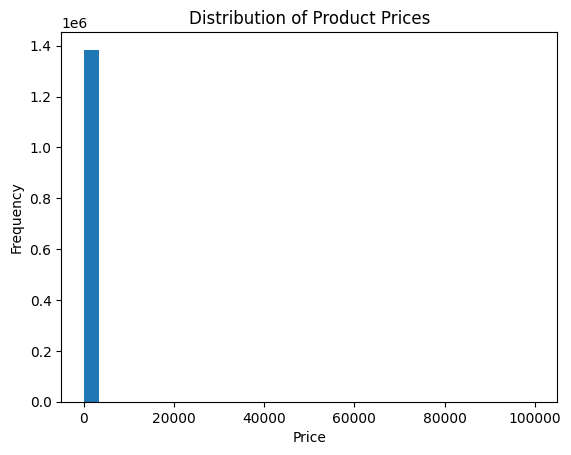

In [19]:
#Creating the histogram
plt.hist(df_instacart["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#Example 6: Visualizing Average Price by Department
#Which departments have the highest average prices?
#Preparing the data
avg_price_by_department = (
    df_instacart
    .groupby("department")["prices"]
    .mean()
    .sort_values(ascending=True)
)

avg_price_by_department


department
snacks              4.272277
other               7.184457
dry goods pasta     7.388252
household           7.402065
canned goods        7.530263
beverages           7.660526
babies              7.682672
deli                7.768707
international       7.799126
frozen              7.801781
bakery              7.833023
pets                7.867823
pantry              7.955316
personal care       7.989259
produce             7.997862
breakfast           8.090261
alcohol             8.126044
bulk                8.211626
missing             8.599139
meat seafood       16.202349
dairy eggs         48.606962
Name: prices, dtype: float64

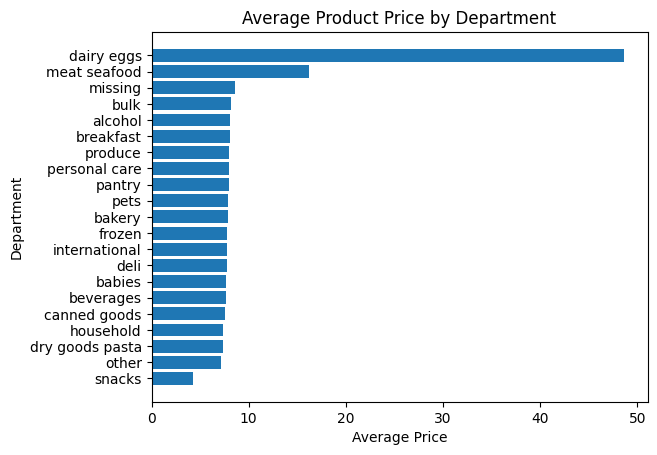

In [30]:
#Creating the chart
avg_price_by_department = (
    df_instacart
    .groupby("department")["prices"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure()
plt.barh(avg_price_by_department.index, avg_price_by_department.values)
plt.title("Average Product Price by Department")
plt.xlabel("Average Price")
plt.ylabel("Department")
plt.show()

In [31]:
#Example 7: Visualizing Reorder Rate by Region
#Which regions have the highest reorder rate?
#Preparing the data
reorder_rate_by_region = (
    df_instacart
    .groupby("region")["reordered"]
    .mean()
    .sort_values(ascending=True)
)

reorder_rate_by_region

region
South        0.596392
Midwest      0.598615
West         0.599062
Northeast    0.602097
Name: reordered, dtype: float64

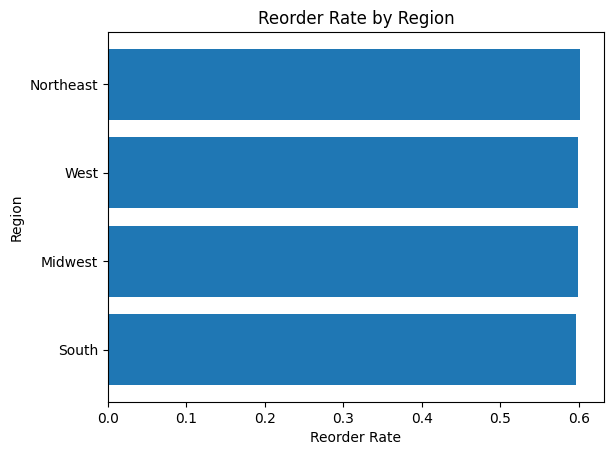

In [32]:
#Creating the chart
reorder_rate_by_region = (
    df_instacart
    .groupby("region")["reordered"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure()
plt.barh(reorder_rate_by_region.index, reorder_rate_by_region.values)
plt.title("Reorder Rate by Region")
plt.xlabel("Reorder Rate")
plt.ylabel("Region")
plt.show()

In [33]:
#Example 8: Visualizing Relationship Between Age and Income
#Is there a visible relationship between customer age and income?
#Preparing the data
customer_profile = df_instacart[
    ["First Name", "Surnam", "Age", "income"]
].drop_duplicates()

customer_profile.head()

,First Name,Surnam,Age,income
0,Linda,Nguyen,31,40423
11,Norma,Chapman,68,64940
42,Janet,Lester,75,115242
51,Peter,Villegas,39,89095
60,Anna,Allison,32,88603


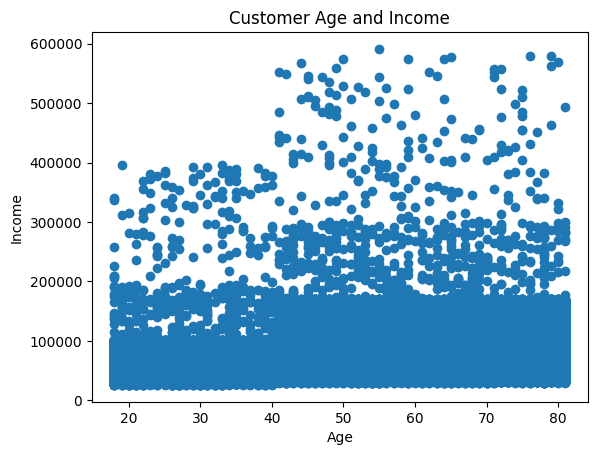

In [34]:
#Creating the chart
customer_profile = df_instacart[
    ["First Name", "Surnam", "Age", "income"]
].drop_duplicates()

plt.figure()
plt.scatter(customer_profile["Age"], customer_profile["income"])
plt.title("Customer Age and Income")
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()